In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/q1_heart_disease.csv')
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.head()

(800, 12)
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


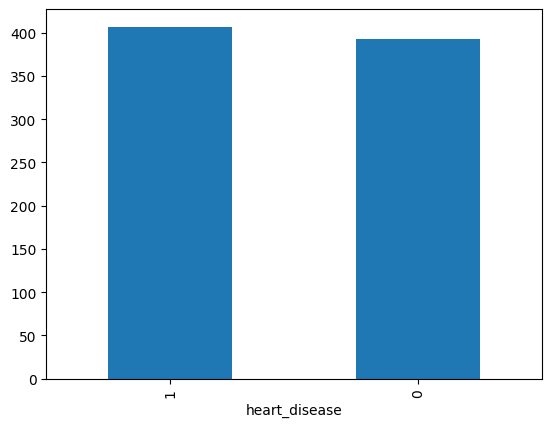

In [3]:
df['heart_disease'].value_counts().plot(kind='bar')
plt.show()

classes are roughly balanced, slightly more disease cases than no-disease

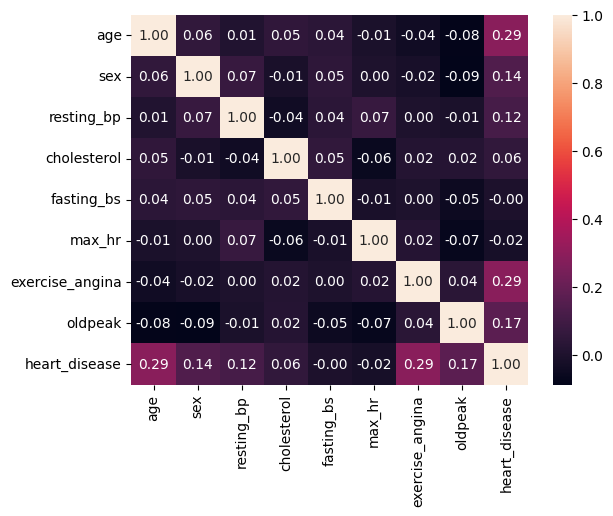

In [4]:
num_cols = df.select_dtypes(include='number').columns.tolist()
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f')
plt.show()

oldpeak and exercise_angina positively correlated with target, max_hr negatively — lower max HR seems linked to disease presence

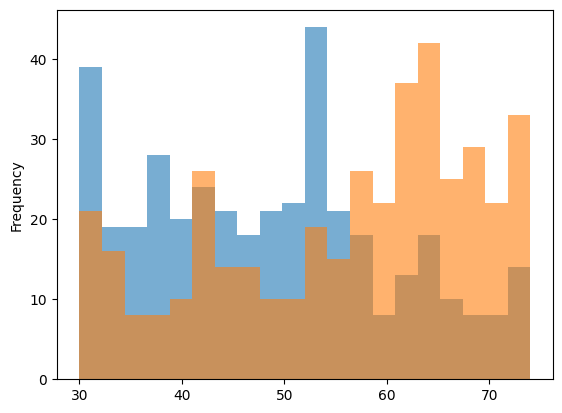

In [5]:
df.groupby('heart_disease')['age'].plot(kind='hist', bins=20, alpha=0.6)
plt.show()

disease cases skew older, roughly 50-65 range dominates — younger patients mostly no-disease

In [6]:
cat_cols = ['chest_pain_type', 'resting_ecg', 'st_slope']
num_feats = [c for c in num_cols if c != 'heart_disease']

# median fill for numerics, mode for categoricals
for c in num_feats:
    df[c] = df[c].fillna(df[c].median())
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

print('nulls left:', df.isnull().sum().sum())

nulls left: 0


used median for numeric columns since it's less affected by outliers, and mode for categorical since there's no better default

In [7]:
df_enc = pd.get_dummies(df, columns=cat_cols)

X = df_enc.drop('heart_disease', axis=1)
y = df_enc['heart_disease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(640, 18) (160, 18)


In [8]:
sc = StandardScaler()
X_train[num_feats] = sc.fit_transform(X_train[num_feats])
X_test[num_feats] = sc.transform(X_test[num_feats])

In [9]:
dt = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
rf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
gb = GradientBoostingClassifier(random_state=42).fit(X_train, y_train)

In [10]:
for name, mdl in [('Decision Tree', dt), ('Random Forest', rf), ('Gradient Boosting', gb)]:
    pred = mdl.predict(X_test)
    print(f'--- {name} ---')
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred))

--- Decision Tree ---
[[56 23]
 [22 59]]
              precision    recall  f1-score   support

           0       0.72      0.71      0.71        79
           1       0.72      0.73      0.72        81

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160

--- Random Forest ---
[[60 19]
 [15 66]]
              precision    recall  f1-score   support

           0       0.80      0.76      0.78        79
           1       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

--- Gradient Boosting ---
[[61 18]
 [18 63]]
              precision    recall  f1-score   support

           0       0.77      0.77      0.77        79
           1       0.78      0.78      0.78        81

    accuracy                           0.78       160
 

Gradient Boosting comes out best — highest F1 on both classes, and better recall on class 1 which matters more here since missing a disease case is worse than a false alarm. DT overfits (perfect train, weaker test), RF is middle ground.

In [11]:
params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4]
}

gs = GridSearchCV(GradientBoostingClassifier(random_state=42), params, cv=5, scoring='f1', n_jobs=-1)
gs.fit(X_train, y_train)
print('best params:', gs.best_params_)
print('best cv f1 :', round(gs.best_score_, 4))

best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
best cv f1 : 0.8329


In [12]:
print('--- baseline GB ---')
print(classification_report(y_test, gb.predict(X_test)))
print('--- tuned GB ---')
print(classification_report(y_test, gs.best_estimator_.predict(X_test)))

--- baseline GB ---
              precision    recall  f1-score   support

           0       0.77      0.77      0.77        79
           1       0.78      0.78      0.78        81

    accuracy                           0.78       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.78      0.78      0.78       160

--- tuned GB ---
              precision    recall  f1-score   support

           0       0.79      0.77      0.78        79
           1       0.78      0.80      0.79        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

